### **NLP Clustering on 20 Newsgroups Dataset**

### **1. Title & Introduction**

Natural Language Processing Assignment

Clustering the 20 Newsgroups Dataset

Objective

This notebook demonstrates:
- Text preprocessing
- Feature extraction (Bag of Words, TF-IDF, Word Embeddings)
- Unsupervised learning (K-Means clustering)
- Evaluation using silhouette score
- Prediction on new unseen documents

### Dataset
We use the 20 Newsgroups dataset, containing ~20,000 documents across 20 topics.

---

In [1]:
# 2. Install & Import Libraries

# Install required libraries
!pip install nltk scikit-learn gensim matplotlib seaborn

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import re
import string

nltk.download('punkt')
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 30.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# 3. Load Dataset

# Load dataset
newsgroups = fetch_20newsgroups(subset='all')

# Extract data and labels
documents = newsgroups.data
labels = newsgroups.target
target_names = newsgroups.target_names

print("Number of documents:", len(documents))
print("Number of categories:", len(target_names))

Number of documents: 18846
Number of categories: 20


In [4]:
import nltk
nltk.download('punkt_tab')

# 4. Text Preprocessing

# Define stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(f"[{string.punctuation}]", "", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

# Apply preprocessing
processed_docs = [preprocess_text(doc) for doc in documents[:2000]]  # subset for speed

print(processed_docs[0][:500])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


mamatha devineni ratnam mr47andrewcmuedu subject pens fans reactions organization post office carnegie mellon pittsburgh pa lines 12 nntppostinghost po4andrewcmuedu sure bashers pens fans pretty confused lack kind posts recent pens massacre devils actually bit puzzled bit relieved however going put end nonpittsburghers relief bit praise pens man killing devils worse thought jagr showed much better regular season stats also lot fo fun watch playoffs bowman let jagr lot fun next couple games since


### Text Preprocessing Steps
- Convert text to lowercase
- Remove punctuation
- Tokenize text into words
- Remove stopwords (common words like "the", "is")

We limit to 2000 documents for faster processing.

In [5]:
# 5. Bag of Words Representation

# Bag of Words
bow_vectorizer = CountVectorizer(max_features=1000)
X_bow = bow_vectorizer.fit_transform(processed_docs)

print("BoW Shape:", X_bow.shape)

BoW Shape: (2000, 1000)


### Bag of Words (BoW)
- Converts text into word frequency vectors
- Each feature represents a word
- Values indicate how often the word appears in the document

In [6]:
# 6. TF-IDF Representation

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(processed_docs)

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (2000, 1000)


### TF-IDF (Term Frequency - Inverse Document Frequency)
- Weighs words based on importance
- Reduces importance of common words
- Highlights unique terms in documents

In [7]:
# 7. Word Embeddings

from gensim.models import Word2Vec

# Tokenized docs
tokenized_docs = [doc.split() for doc in processed_docs]

# Train simple Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_docs, vector_size=100, window=5, min_count=2)

# Example word vector
print("Vector for 'computer':")
print(w2v_model.wv['computer'][:10])

Vector for 'computer':
[-0.9029627   0.43235928  1.3485694  -0.28553918  0.6240416  -0.4213881
 -0.2585905   2.050466   -0.3989738  -0.5160984 ]


### Word Embeddings
- Capture semantic meaning of words
- Words with similar meanings have similar vectors
- Example: "computer" and "technology" may be close in vector space

In [8]:
# 8. K-Means Clustering

# Number of clusters
k = 20

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_tfidf)

clusters = kmeans.labels_

In [9]:
# Evaluate Model

score = silhouette_score(X_tfidf, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.01599576432419384


### Silhouette Score
- Measures clustering quality
- Range: -1 to 1
- Higher = better clustering

In [10]:
# 10. Top Terms per Cluster

terms = tfidf_vectorizer.get_feature_names_out()

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top_terms = [terms[ind] for ind in center.argsort()[-10:]]

    print(f"\nCluster {i}:")
    print(", ".join(top_terms))


Cluster 0:
university, distribution, organization, sell, interested, lines, subject, offer, monitor, sale

Cluster 1:
think, government, get, one, like, dont, article, writes, would, people

Cluster 2:
hockey, players, baseball, play, nhl, year, go, games, team, game

Cluster 3:
subject, organization, atheists, would, nntppostinghost, energy, writes, technology, institute, keith

Cluster 4:
port, speed, isa, memory, system, controller, cards, bus, video, card

Cluster 5:
usa, computer, distribution, article, writes, nntppostinghost, organization, subject, lines, university

Cluster 6:
people, history, studies, david, muslim, armenians, turkey, armenia, armenian, turkish

Cluster 7:
people, sin, christians, christian, one, church, christ, bible, jesus, god

Cluster 8:
im, university, ca, would, subject, lines, organization, motif, thanks, info

Cluster 9:
things, also, could, program, earth, science, would, nasa, station, space

Cluster 10:
lines, use, subject, ftp, 31, university, pro

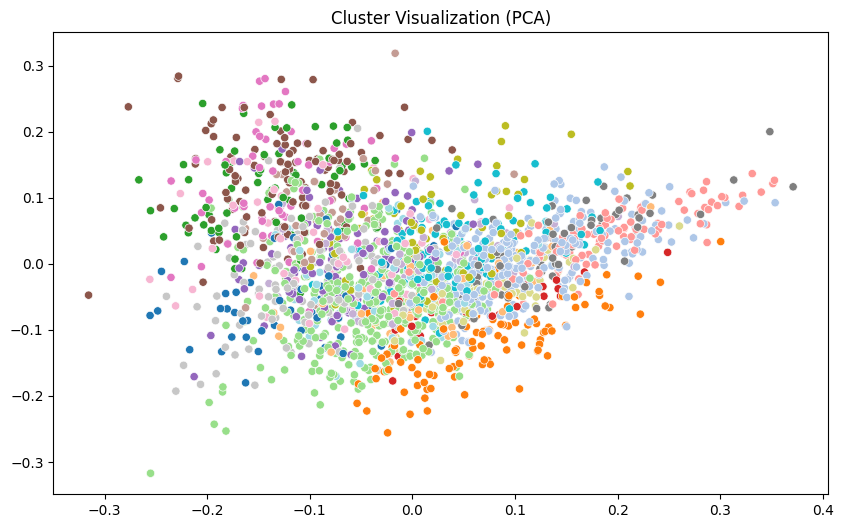

In [11]:
# 11. Visualization

# Reduce dimensions using PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_reduced[:,0], y=X_reduced[:,1], hue=clusters, palette='tab20', legend=None)
plt.title("Cluster Visualization (PCA)")
plt.show()

In [12]:
# 12. Predict New Documents

def predict_cluster(text):
    processed = preprocess_text(text)
    vector = tfidf_vectorizer.transform([processed])
    cluster = kmeans.predict(vector)
    return cluster[0]

# Test example
new_text = "The graphics card in my computer is amazing"
print("Predicted cluster:", predict_cluster(new_text))

Predicted cluster: 4


### **# 13. Conclusion**

## Conclusion

- Successfully preprocessed text data
- Implemented BoW and TF-IDF
- Applied K-Means clustering
- Evaluated model using silhouette score
- Visualized clusters
- Predicted clusters for new documents

### Insights
- TF-IDF performs better than BoW for clustering
- Some clusters clearly represent topics like technology, sports, politics
- Word embeddings provide semantic understanding but were not directly used for clustering

---